In [2]:
!pip install xgboost shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 12.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.8 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 16.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]4/5 [shap]]te]


In [ ]:
import pandas as pd
# import numpy as np
# from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
# from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
print("Libraries imported successfully.")
# 1. 가상 데이터 생성 (샘플)
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/accidents.csv')
print(df.head())
df.to_csv('accidents.csv', index=False)

--- 모델 평가 결과 ---
정확도(Accuracy): 0.78
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       172
           1       0.05      0.04      0.04        28

    accuracy                           0.78       200
   macro avg       0.45      0.47      0.46       200
weighted avg       0.74      0.78      0.76       200



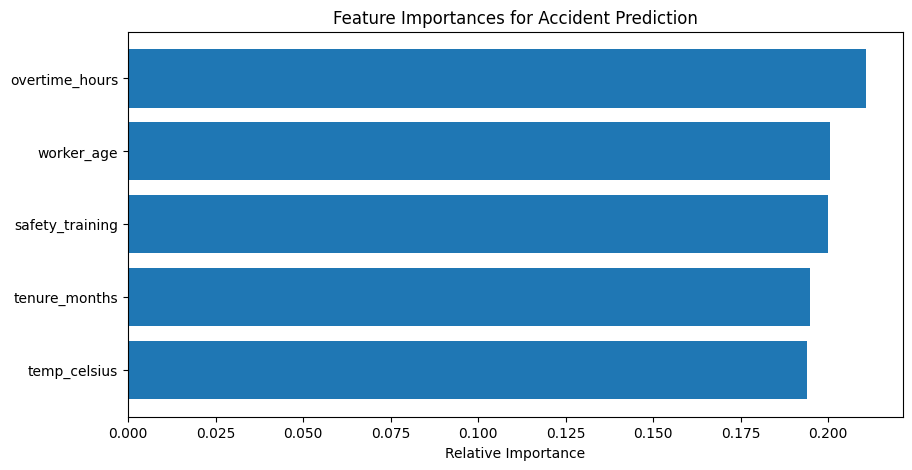

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# 1. 가상 데이터 생성 (샘플)
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/accidents.csv')
print(df.head())

# df = pd.DataFrame(data)

# 2. 데이터 분리 (특성 데이터와 라벨 데이터)
X = df.drop('accident_occurred', axis=1)
y = df['accident_occurred']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. XGBoost 모델 생성 및 학습
# scale_pos_weight는 산재 데이터처럼 사고(1)가 적은 불균형 데이터 처리에 도움을 줍니다.
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=9, # 사고 발생 확률이 10%일 때 약 9배 가중치
    random_state=42
)

model.fit(X_train, y_train)

# 4. 예측 및 평가
y_pred = model.predict(X_test)

print("--- 모델 평가 결과 ---")
print(f"정확도(Accuracy): {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred))

# 5. 주요 변수 시각화 (어떤 요인이 사고에 큰 영향을 주었나?)
importances = model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(10, 5))
plt.title('Feature Importances for Accident Prediction')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()


In [ ]:
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

# 1. 데이터 불러오기 (본인의 파일 경로로 수정하세요)
# 예: df = pd.read_csv('safety_data.csv')
# 여기서는 예시를 위해 앞서 만든 df를 사용한다고 가정합니다.
# df = pd.read_csv('파일명.csv') 

# 2. 분석 준비 (X: 입력 변수들, y: 사고 여부 타겟)
target_column = 'accident_occurred' # 실제 파일의 타겟 컬럼명으로 수정
X = df.drop(target_column, axis=1)
y = df[target_column]

# 3. 모델 재학습 (SHAP 확인을 위해 최적화된 상태)
model = xgb.XGBClassifier().fit(X, y)

# 4. SHAP 해석기 생성 및 값 계산
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# 5. 시각화 (한글 깨짐 방지 설정이 필요할 수 있습니다)
plt.rcParams['axes.unicode_minus'] = False 

# [그래프 1] 전체적인 사고 원인 순위 (Summary Plot)
print("항목별 사고 기여도 순위를 생성합니다...")
shap.summary_plot(shap_values, X)

# [그래프 2] 특정 변수가 사고 확률에 미치는 영향 (Dependence Plot)
# 예: 근속기간(tenure_months)이 늘어날수록 사고 위험이 어떻게 변하는지 확인
feature_to_plot = X.columns[0] # 첫 번째 컬럼 예시, 'overtime_hours' 등으로 수정 가능
shap.dependence_plot(feature_to_plot, shap_values, X)
